In [1]:
# In this notebook we will look at how to find the best model parameters for our problem with the help of keras_tuner

In [3]:
# Now let's all the necessary libraries here 

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

import tensorflow as tf
import keras 
import keras_tuner as kt

from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import Input,Activation
from keras.layers import Dropout,Dense,BatchNormalization

import os
# Suppress TensorFlow logging (0 = all logs, 1 = hide INFO, 2 = hide WARNING, 3 = hide ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 


In [4]:
X,y = make_moons(
                    n_samples = 300,
                    noise = 0.15,
                    random_state=40
)

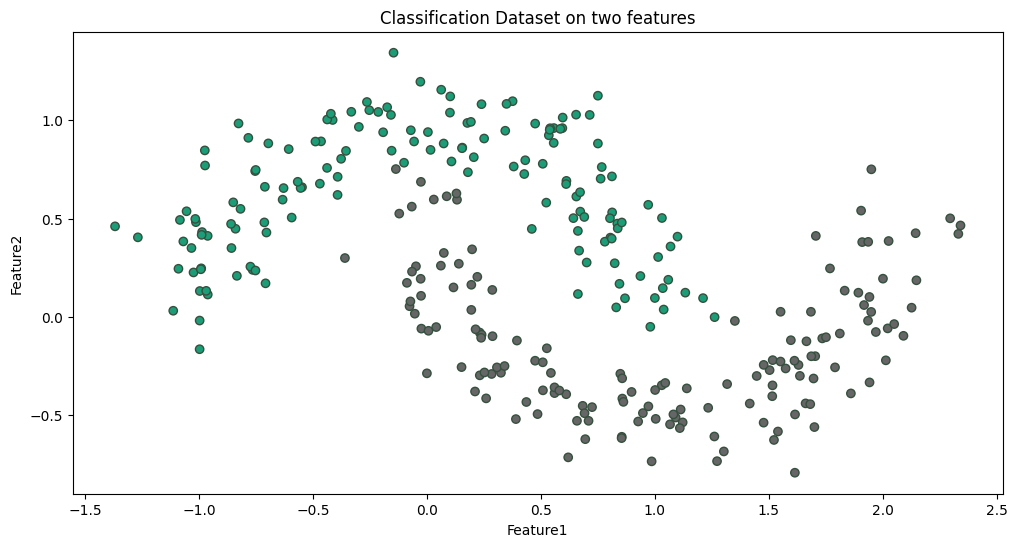

In [5]:
plt.figure(figsize=(12,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='Dark2',edgecolors="#36503F")
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.title('Classification Dataset on two features')
plt.show()

In [6]:
# Now split them again intro training and test set 
X_train,X_test,y_train,y_test = train_test_split(
                                                    X,y,
                                                    test_size=0.2,
                                                    random_state=40
)

In [7]:
# Template
'''
def build_model(hp):
    model = keras.Sequential()
    

    num_layers = hp.Int('num_layers', min_value=1, max_value=4, default=2)
    
    for i in range(num_layers):
    
        units = hp.Int(f'units_{i}', min_value=32, max_value=256, step=32)
        activation = hp.Choice(f'activation_{i}', values=['relu', 'tanh', 'elu'])
        
        if i == 0:
            model.add(Input(shape=(X.shape[1],)))
            model.add(Dense(units=units))
            model.add(Activation(activation))
        else:
            model.add(Dense(units=units))
            model.add(Activation(activation))
            
        dropout_rate = hp.Float(f'dropout_{i}', min_value=0.0, max_value=0.5, step=0.1)
        model.add(Dropout(rate=dropout_rate))
        
    model.add(Dense(1)) 
    model.add(Activation('sigmoid'))

    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

'''

"\ndef build_model(hp):\n    model = keras.Sequential()\n    \n\n    num_layers = hp.Int('num_layers', min_value=1, max_value=4, default=2)\n    \n    for i in range(num_layers):\n    \n        units = hp.Int(f'units_{i}', min_value=32, max_value=256, step=32)\n        activation = hp.Choice(f'activation_{i}', values=['relu', 'tanh', 'elu'])\n        \n        if i == 0:\n            model.add(Input(shape=(X.shape[1],)))\n            model.add(Dense(units=units))\n            model.add(Activation(activation))\n        else:\n            model.add(Dense(units=units))\n            model.add(Activation(activation))\n            \n        dropout_rate = hp.Float(f'dropout_{i}', min_value=0.0, max_value=0.5, step=0.1)\n        model.add(Dropout(rate=dropout_rate))\n        \n    model.add(Dense(1)) \n    model.add(Activation('sigmoid'))\n\n    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])\n    \n    model.compile(\n        optimizer=keras.optimizers.Adam(learning_rat

In [29]:
# Basically to tune the model we need to pass a build_model function to the tuner with params as hp
# We can here specify any speicic param to search or multiple params at once
# There is gridsearch , randomsearch and hyperband 
# For convenience I will use hyperband here

def build_model(hp):

    # Instantiate the model
    model = Sequential()

    # Now we will also do a search for the perfect no of layers as well with no of neurons per layer

    num_layers = hp.Int(
                            'hidden_layers',
                            min_value = 2,
                            max_value = 10,
                            step = 1
    )

    # I explicitly set this cause I want to tune differnt no of neurons for each layer
    for i in range(num_layers) : 

        # Instantiate the search variable
        neuron_units = hp.Int(  
                                f'hidden_units_{i}', # The name for these search i
                                min_value=2, # The lower_boundary
                                max_value=26, # The upper_boundary
                                step=2 # Steps = 2,4,6...26
                            ) 
        # Searching for the perfect Activation function
        activation = hp.Choice(
                                f'hidden_activation_{i}' ,     # The name for these search i
                                values = ['relu','tanh','elu'] # The choices stored in values list
        )
        
        model.add(Dense(neuron_units))
        model.add(Activation(activation))

    # Output layer 
    model.add(Dense(1)) 
    model.add(Activation('sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


In [30]:
# Hyperband cuts poorly performing trials early to save time
tuner = kt.Hyperband(
    hypermodel=build_model,                           # Pass the function containing the model to search
    objective='val_accuracy',                         # Target metric to maximize/minimize depending on the problem
    max_epochs=20,                                    # Max epochs for a single model
    factor=3,                                         # Reduction factor for resource allocation
    directory='keras_tuner_dir',                      # Folder where progress logs are saved
    project_name='tuning_layers_nodes_and_activation_func'          
)

In [31]:
# 1. Define an EarlyStopping callback to maximize efficiency
stop_early = EarlyStopping(
    monitor='val_loss',             # Which value to look for convergence early
    patience=5,                     # No of values to wait until declaring converged
    restore_best_weights=True
)

# 2. Launch the search execution loop - To initiate the search
tuner.search(
    X_train, y_train,                   # The variables to train model
    # epochs=50,                          # No of epochs # Either leave this or keep this = max_epochs in the tuner 
    validation_data=(X_test,y_test),    # Validation set 
    callbacks=[stop_early]              # Pass the EarlyStopping function here 
)

Trial 30 Complete [00h 00m 10s]
val_accuracy: 0.8666666746139526

Best val_accuracy So Far: 0.9833333492279053
Total elapsed time: 00h 04m 13s


In [32]:
tuner.results_summary(num_trials=1) # Best model_summary

Results summary
Results in keras_tuner_dir/tuning_layers_nodes_and_activation_func
Showing 1 best trials
Objective(name="val_accuracy", direction="max")

Trial 0028 summary
Hyperparameters:
hidden_layers: 10
hidden_units_0: 10
hidden_activation_0: elu
hidden_units_1: 8
hidden_activation_1: relu
hidden_units_2: 12
hidden_activation_2: relu
hidden_units_3: 10
hidden_activation_3: elu
hidden_units_4: 16
hidden_activation_4: elu
hidden_units_5: 26
hidden_activation_5: elu
hidden_units_6: 14
hidden_activation_6: relu
hidden_units_7: 22
hidden_activation_7: relu
hidden_units_8: 2
hidden_activation_8: elu
hidden_units_9: 4
hidden_activation_9: relu
tuner/epochs: 20
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.9833333492279053


In [35]:
# 1. Extract the top set of hyperparameters found during the search
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# 2. Automatically rebuild the exact winning architecture
best_model = tuner.hypermodel.build(best_hps)

In [36]:
# Train the best model on complete dataset 
history = best_model.fit(
    X_train, y_train, 
    epochs=50, 
    validation_data=(X_test, y_test),
    callbacks=[stop_early]
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 330ms/step - accuracy: 0.5042 - loss: 0.6896 - val_accuracy: 0.4833 - val_loss: 0.6869
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5042 - loss: 0.6799 - val_accuracy: 0.4833 - val_loss: 0.6756
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5042 - loss: 0.6634 - val_accuracy: 0.4833 - val_loss: 0.6583
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5208 - loss: 0.6372 - val_accuracy: 0.5833 - val_loss: 0.6340
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6583 - loss: 0.6047 - val_accuracy: 0.6667 - val_loss: 0.6013
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7208 - loss: 0.5657 - val_accuracy: 0.7500 - val_loss: 0.5692
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7417 - loss: 0.5270 - val_accuracy: 0.8167 - val_loss: 0.5362
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8333 - loss: 0.4954 - val_accuracy: 0.8333 - val_loss: 0.5135

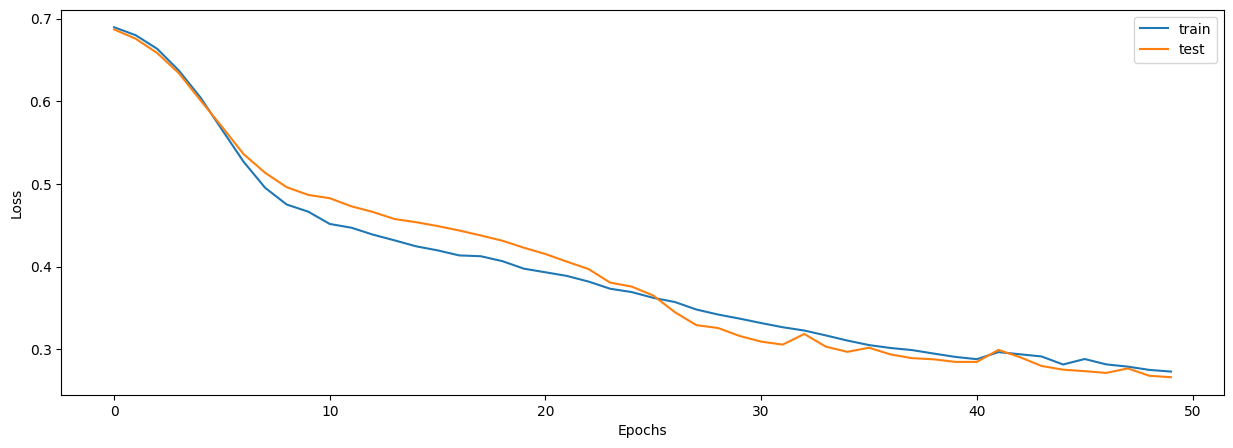

In [37]:
# Lets plot the loss on train and test set to look for the performance of the best model
plt.figure(figsize=(15,5))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


The decision boundary made by the model :  
 
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step


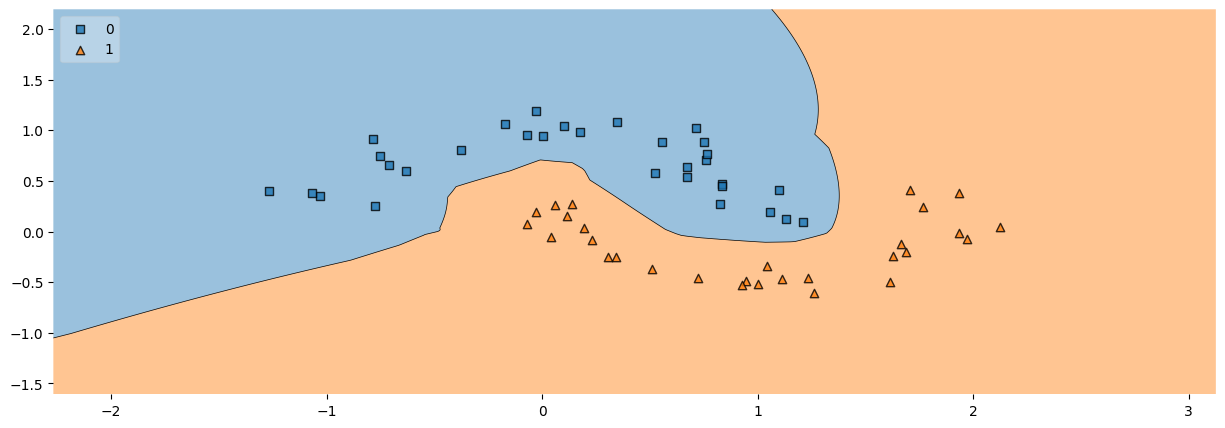

In [38]:
print(f'The decision boundary made by the model :  \n ')
plt.figure(figsize=(15,5))
plot_decision_regions(X_test, y_test.ravel().astype(int), clf = best_model, legend=2)
plt.show()

In [39]:
# Now the accuracy is really good but again theere is a jargerdness see in the loss graphs
# But the model was able to determine the boundary exceptionally well this time